# 🎤 Voice Command Recognition — Mini Alexa
### ECE Mini Project | Signal Processing + Machine Learning

**Pipeline:**
1. Download Google Speech Commands dataset
2. Preprocess audio & extract MFCC features
3. Train Random Forest + CNN models
4. Evaluate with confusion matrix
5. Live microphone prediction

**Commands recognized:** `yes · no · up · down · on · off`

---
## 📦 Cell 1 — Install & Import Libraries

In [ ]:
# Install required packages
!pip install librosa soundfile -q

import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('✅ All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Librosa version: {librosa.__version__}')

✅ All libraries imported successfully!
TensorFlow version: 2.20.0
Librosa version: 0.11.0


---
## 📥 Cell 2 — Download Google Speech Commands Dataset

In [ ]:
# Download the Google Speech Commands dataset (v0.01 ~2.4GB, takes ~2 min)
# We will only use a small subset of commands

import urllib.request
import tarfile

DATA_DIR = '/content/speech_data'
ARCHIVE  = '/content/speech_commands.tar.gz'
URL      = 'http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz'

if not os.path.exists(DATA_DIR):
    print('⏬ Downloading dataset (~2.4 GB) ... please wait ...')
    urllib.request.urlretrieve(URL, ARCHIVE)
    print('📂 Extracting ...')
    os.makedirs(DATA_DIR, exist_ok=True)
    with tarfile.open(ARCHIVE, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    print('✅ Dataset ready!')
else:
    print('✅ Dataset already downloaded.')

# List available commands
all_commands = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d)) and not d.startswith('_')
])
print(f'\n📋 Available commands ({len(all_commands)}): {all_commands}')

⏬ Downloading dataset (~2.4 GB) ... please wait ...
📂 Extracting ...
✅ Dataset ready!

📋 Available commands (30): ['bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'four', 'go', 'happy', 'house', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'wow', 'yes', 'zero']


---
## ⚙️ Cell 3 — Configuration & Commands Selection

In [ ]:
# ============================================================
# CONFIGURATION — tweak these as you like
# ============================================================
COMMANDS      = ['yes', 'no', 'up', 'down', 'on', 'off']   # commands to classify
SAMPLES_PER_CLASS = 500    # how many audio clips per command (max ~2000 each)
SAMPLE_RATE   = 16000      # Hz — all audio resampled to this
DURATION      = 1.0        # seconds — clip length
N_MFCC        = 40         # number of MFCC coefficients
TEST_SIZE     = 0.2        # 80% train, 20% test
RANDOM_STATE  = 42
# ============================================================

print('🎯 Target commands:', COMMANDS)
print(f'📊 Samples per class: {SAMPLES_PER_CLASS}')
print(f'🎵 Sample rate: {SAMPLE_RATE} Hz | Duration: {DURATION}s')
print(f'🔢 MFCC coefficients: {N_MFCC} → feature vector size: {N_MFCC * 2} (mean + std)')

🎯 Target commands: ['yes', 'no', 'up', 'down', 'on', 'off']
📊 Samples per class: 500
🎵 Sample rate: 16000 Hz | Duration: 1.0s
🔢 MFCC coefficients: 40 → feature vector size: 80 (mean + std)


---
## 🔍 Cell 4 — Audio Visualization (Waveform + Spectrogram + MFCC)

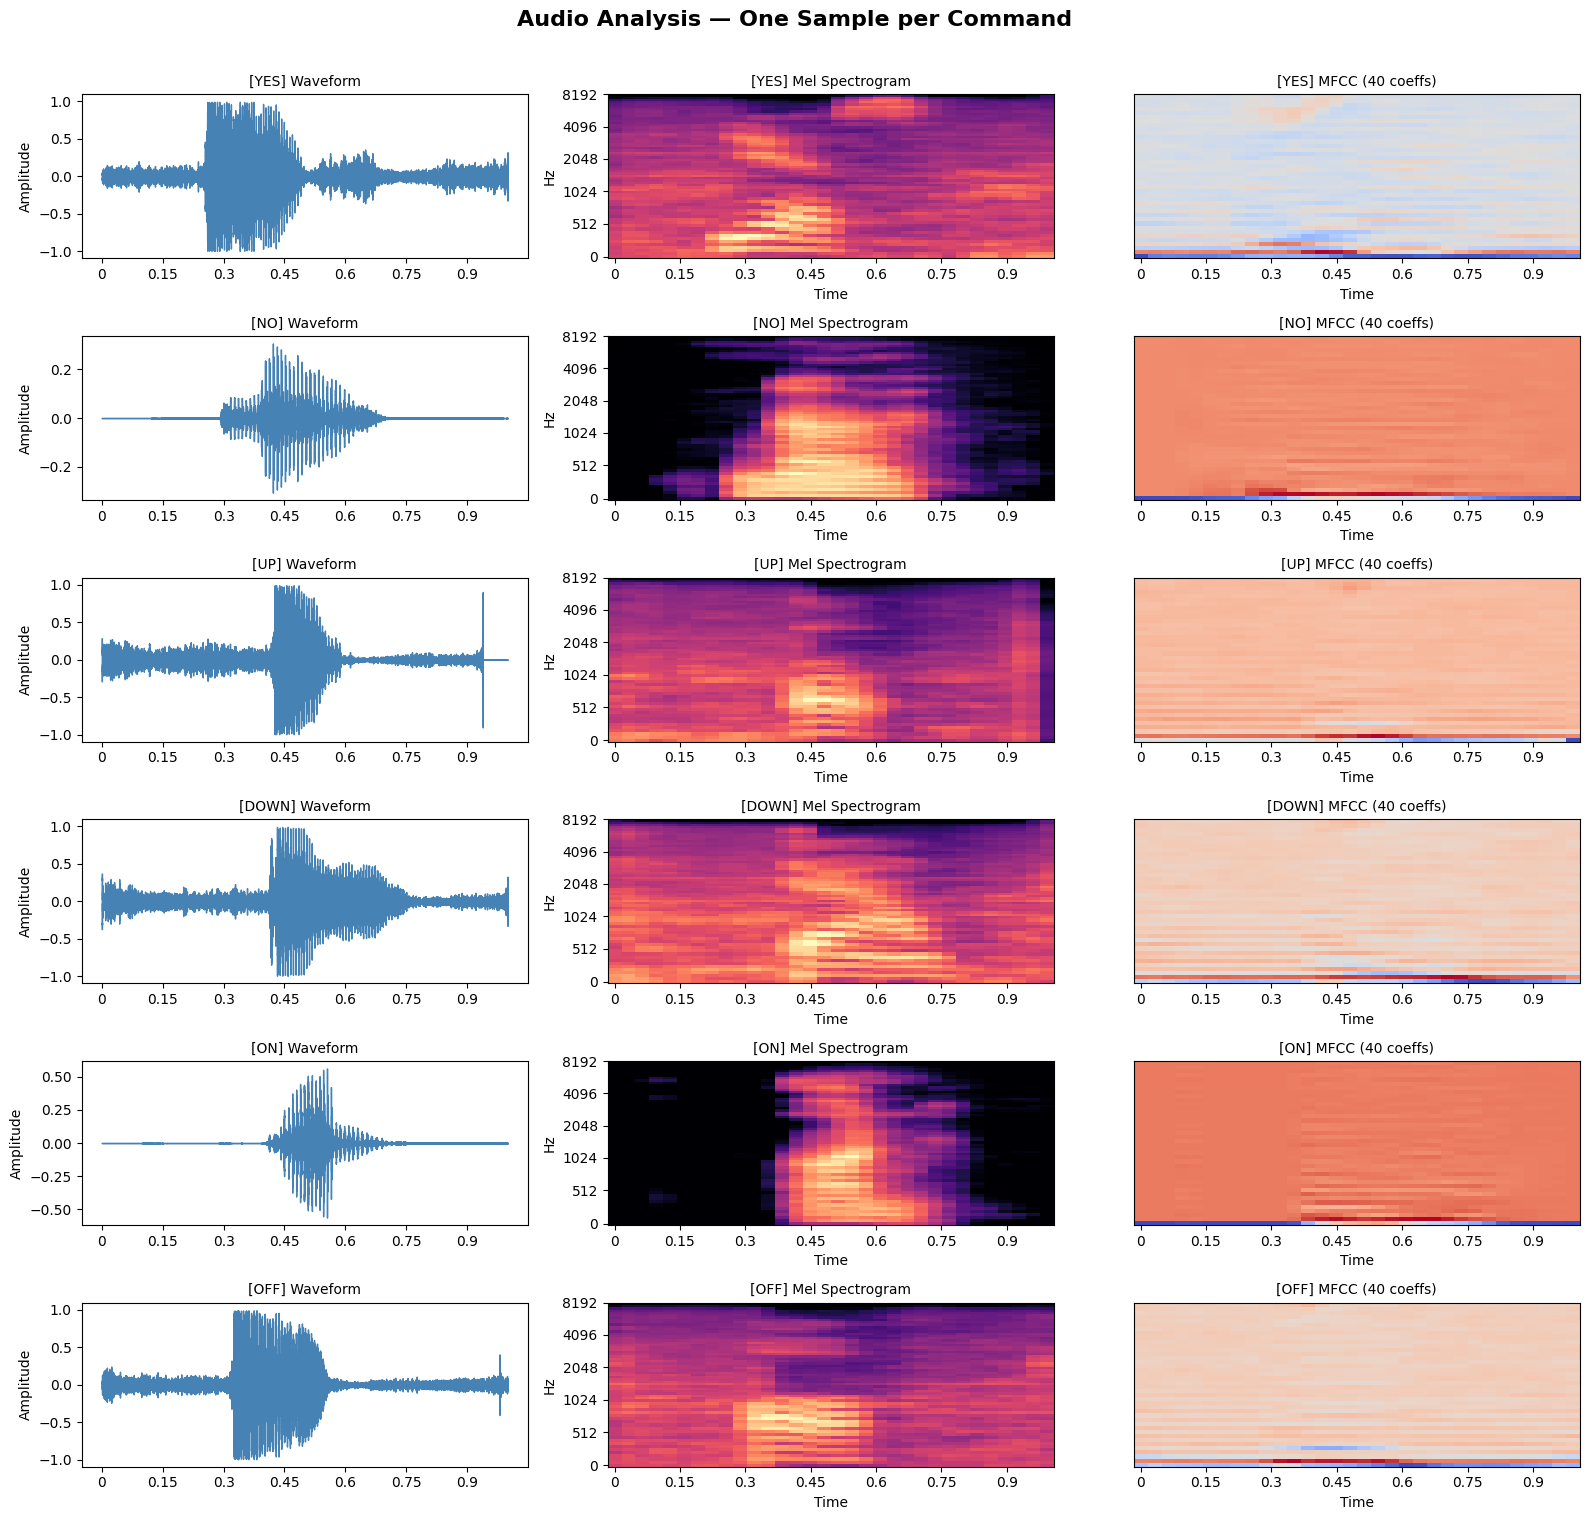

✅ Visualization saved to /content/audio_visualization.png


In [ ]:
# Visualize one sample from each command
fig, axes = plt.subplots(len(COMMANDS), 3, figsize=(16, len(COMMANDS) * 2.5))
fig.suptitle('Audio Analysis — One Sample per Command', fontsize=16, fontweight='bold', y=1.01)

for i, cmd in enumerate(COMMANDS):
    files = glob.glob(f'{DATA_DIR}/{cmd}/*.wav')
    if not files:
        print(f'⚠️  No files found for: {cmd}')
        continue

    y, sr = librosa.load(files[0], sr=SAMPLE_RATE, duration=DURATION)
    y = librosa.util.fix_length(y, size=int(SAMPLE_RATE * DURATION))

    # Waveform
    ax = axes[i][0]
    librosa.display.waveshow(y, sr=sr, ax=ax, color='steelblue')
    ax.set_title(f'[{cmd.upper()}] Waveform', fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('Amplitude')

    # Mel Spectrogram
    ax = axes[i][1]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, ax=ax, x_axis='time', y_axis='mel', cmap='magma')
    ax.set_title(f'[{cmd.upper()}] Mel Spectrogram', fontsize=10)

    # MFCC
    ax = axes[i][2]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    librosa.display.specshow(mfcc, sr=sr, ax=ax, x_axis='time', cmap='coolwarm')
    ax.set_title(f'[{cmd.upper()}] MFCC ({N_MFCC} coeffs)', fontsize=10)

plt.tight_layout()
plt.savefig('/content/audio_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualization saved to /content/audio_visualization.png')

---
## 🧪 Cell 5 — Feature Extraction (MFCC)

In [ ]:
def extract_mfcc_flat(file_path, n_mfcc=N_MFCC, sr=SAMPLE_RATE, duration=DURATION):
    """Load a .wav file and return flat MFCC feature vector (mean + std)."""
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    y = librosa.util.fix_length(y, size=int(sr * duration))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])  # shape: (n_mfcc*2,)

def extract_mfcc_2d(file_path, n_mfcc=N_MFCC, sr=SAMPLE_RATE, duration=DURATION, max_frames=87):
    """Return 2D MFCC matrix for CNN input."""
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    y = librosa.util.fix_length(y, size=int(sr * duration))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Pad or truncate to fixed number of frames
    if mfcc.shape[1] < max_frames:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_frames - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_frames]
    return mfcc  # shape: (n_mfcc, max_frames)


print('⏳ Extracting MFCC features from all audio files ...')
print('   (This may take 2-4 minutes for 500 samples per class)\n')

X_flat, X_2d, y_labels = [], [], []

for cmd in COMMANDS:
    files = glob.glob(f'{DATA_DIR}/{cmd}/*.wav')[:SAMPLES_PER_CLASS]
    success = 0
    for f in files:
        try:
            X_flat.append(extract_mfcc_flat(f))
            X_2d.append(extract_mfcc_2d(f))
            y_labels.append(cmd)
            success += 1
        except Exception as e:
            pass
    print(f'  ✅ [{cmd:>6}] — {success} samples extracted')

X_flat   = np.array(X_flat,   dtype=np.float32)
X_2d     = np.array(X_2d,     dtype=np.float32)
y_labels = np.array(y_labels)

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)

print(f'\n📦 Feature matrix (flat):  {X_flat.shape}  → for RF / SVM')
print(f'📦 Feature matrix (2D):    {X_2d.shape}  → for CNN')
print(f'🏷️  Classes: {le.classes_}')

⏳ Extracting MFCC features from all audio files ...
   (This may take 2-4 minutes for 500 samples per class)

  ✅ [   yes] — 500 samples extracted
  ✅ [    no] — 500 samples extracted
  ✅ [    up] — 500 samples extracted
  ✅ [  down] — 500 samples extracted
  ✅ [    on] — 500 samples extracted
  ✅ [   off] — 500 samples extracted

📦 Feature matrix (flat):  (3000, 80)  → for RF / SVM
📦 Feature matrix (2D):    (3000, 40, 87)  → for CNN
🏷️  Classes: ['down' 'no' 'off' 'on' 'up' 'yes']


---
## 🌳 Cell 6 — Model A: Random Forest Classifier

In [ ]:
# Train / test split for flat features
X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_flat, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

# Standardize
scaler = StandardScaler()
X_train_f = scaler.fit_transform(X_train_f)
X_test_f  = scaler.transform(X_test_f)

print('🌳 Training Random Forest ...')
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_f, y_train)

y_pred_rf = rf_model.predict(X_test_f)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f'\n🎯 Random Forest Test Accuracy: {rf_acc * 100:.2f}%')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

🌳 Training Random Forest ...

🎯 Random Forest Test Accuracy: 63.00%

📋 Classification Report:
              precision    recall  f1-score   support

        down       0.55      0.61      0.58       100
          no       0.55      0.48      0.51       100
         off       0.63      0.74      0.68       100
          on       0.56      0.46      0.51       100
          up       0.65      0.67      0.66       100
         yes       0.84      0.82      0.83       100

    accuracy                           0.63       600
   macro avg       0.63      0.63      0.63       600
weighted avg       0.63      0.63      0.63       600



---
## 🧠 Cell 7 — Model B: CNN on MFCC Spectrogram

In [ ]:
# Reshape for CNN: (samples, height, width, channels)
X_cnn = X_2d[..., np.newaxis]  # shape: (N, N_MFCC, max_frames, 1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cnn, y_enc, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

# Normalize
X_train_c = (X_train_c - X_train_c.mean()) / (X_train_c.std() + 1e-8)
X_test_c  = (X_test_c  - X_train_c.mean()) / (X_train_c.std() + 1e-8)

# One-hot encode labels for CNN
y_train_oh = keras.utils.to_categorical(y_train_c, num_classes=len(COMMANDS))
y_test_oh  = keras.utils.to_categorical(y_test_c,  num_classes=len(COMMANDS))

input_shape = X_train_c.shape[1:]  # (N_MFCC, max_frames, 1)

# Build CNN
def build_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(input_shape, len(COMMANDS))
cnn_model.summary()

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

print('\n🧠 Training CNN ...')
history = cnn_model.fit(
    X_train_c, y_train_oh,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_c, y_test_oh, verbose=0)
print(f'\n🎯 CNN Test Accuracy: {cnn_acc * 100:.2f}%')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 87, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 87, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 43, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,854 (433.02 KB)

 Trainable params: 110,406 (431.27 KB)

 Non-trainable params: 448 (1.75 KB)


🧠 Training CNN ...
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.3216 - loss: 1.6811 - val_accuracy: 0.1833 - val_loss: 1.9220 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4750 - loss: 1.3248 - val_accuracy: 0.1833 - val_loss: 2.5802 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5819 - loss: 1.1033 - val_accuracy: 0.1833 - val_loss: 3.1209 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6740 - loss: 0.8702 - val_accuracy: 0.1944 - val_loss: 1.8383 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7471 - loss: 0.7153 - val_accuracy: 0.1833 - val_loss: 4.3648 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7799 - loss: 0.5899 - val_accuracy: 0.3583 - val_loss: 1.6783 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8108 - loss: 

---
## 📊 Cell 8 — Training Curves + Confusion Matrices

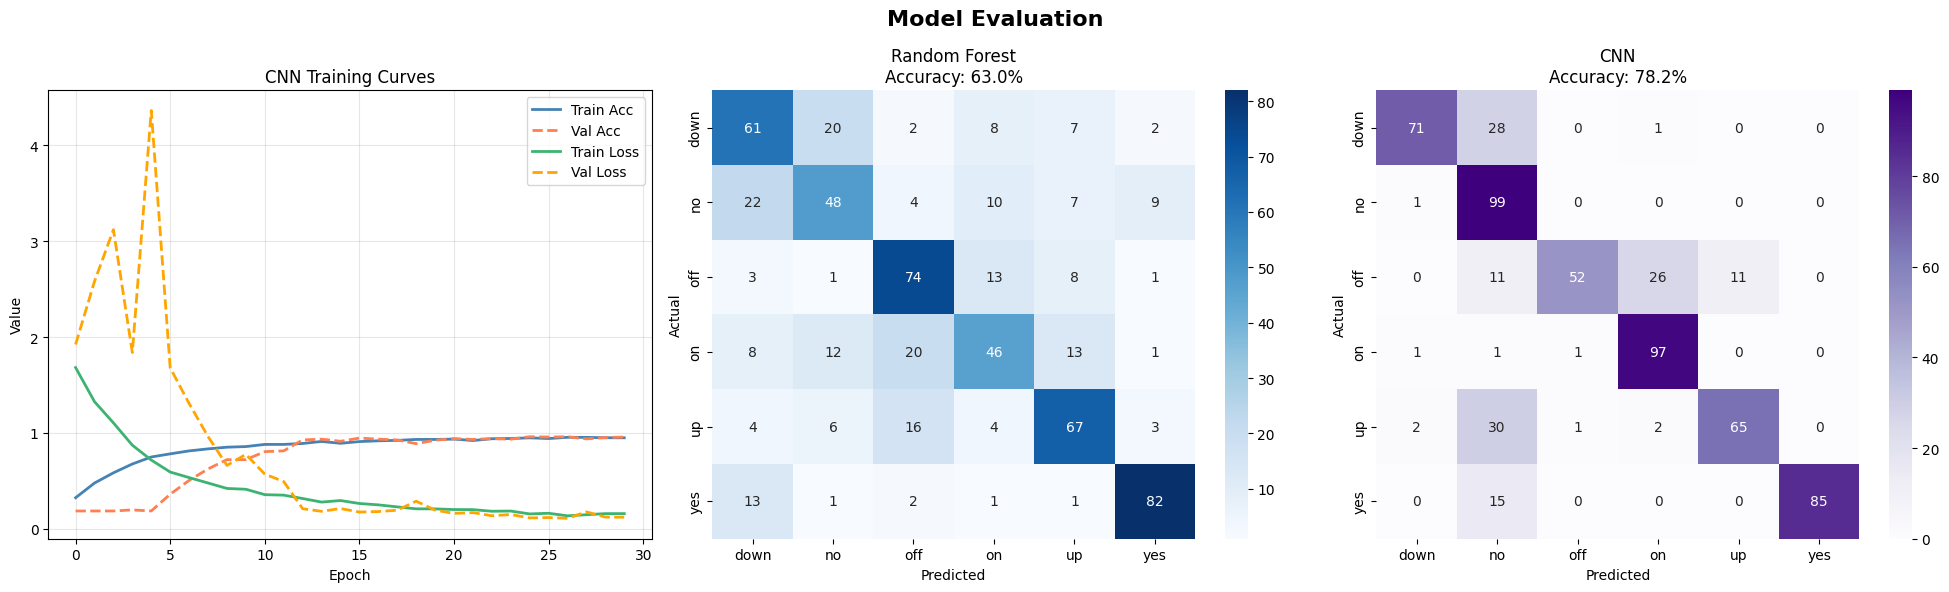


       MODEL COMPARISON SUMMARY
  Random Forest : 63.00% accuracy
  CNN           : 78.17% accuracy
  🏆 Winner: CNN


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# --- CNN training curves ---
ax = axes[0]
ax.plot(history.history['accuracy'],     label='Train Acc',  color='steelblue', linewidth=2)
ax.plot(history.history['val_accuracy'], label='Val Acc',    color='coral',     linewidth=2, linestyle='--')
ax.plot(history.history['loss'],         label='Train Loss', color='mediumseagreen', linewidth=2)
ax.plot(history.history['val_loss'],     label='Val Loss',   color='orange',    linewidth=2, linestyle='--')
ax.set_title('CNN Training Curves')
ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Random Forest confusion matrix ---
ax = axes[1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Random Forest\nAccuracy: {rf_acc*100:.1f}%')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# --- CNN confusion matrix ---
ax = axes[2]
y_pred_cnn = np.argmax(cnn_model.predict(X_test_c, verbose=0), axis=1)
cm_cnn = confusion_matrix(y_test_c, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'CNN\nAccuracy: {cnn_acc*100:.1f}%')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

# Model comparison summary
print('\n' + '='*45)
print('       MODEL COMPARISON SUMMARY')
print('='*45)
print(f'  Random Forest : {rf_acc*100:.2f}% accuracy')
print(f'  CNN           : {cnn_acc*100:.2f}% accuracy')
print('='*45)
winner = 'CNN' if cnn_acc > rf_acc else 'Random Forest'
print(f'  🏆 Winner: {winner}')

---
## 💾 Cell 9 — Save Models

In [ ]:
import joblib

# Save Random Forest model + scaler + label encoder
joblib.dump(rf_model, '/content/rf_voice_model.pkl')
joblib.dump(scaler,   '/content/rf_scaler.pkl')
joblib.dump(le,       '/content/label_encoder.pkl')
print('✅ Random Forest model saved: /content/rf_voice_model.pkl')

# Save CNN model
cnn_model.save('/content/cnn_voice_model.h5')
print('✅ CNN model saved:           /content/cnn_voice_model.h5')

# Save label list for inference
np.save('/content/label_classes.npy', le.classes_)
print('✅ Label classes saved:       /content/label_classes.npy')
print(f'\n🏷️  Labels: {le.classes_}')

✅ Random Forest model saved: /content/rf_voice_model.pkl
✅ CNN model saved:           /content/cnn_voice_model.h5
✅ Label classes saved:       /content/label_classes.npy

🏷️  Labels: ['down' 'no' 'off' 'on' 'up' 'yes']


---
## 🎙️ Cell 10 — Live Microphone Prediction
> **Instructions:** Run this cell → Allow microphone access → Speak a command → See prediction!
>
> Works best in **Chrome/Edge** browser.

In [ ]:
# Cell 10 — Live Microphone Prediction (FIXED)
!apt-get install -y ffmpeg -q
!pip install pydub -q

from IPython.display import Javascript, HTML, display, Audio
from google.colab import output
import base64, io, tempfile, os
import numpy as np
import librosa
from pydub import AudioSegment

# ── helper: predict from raw audio array ──────────────────
def predict_from_array(y_raw, sr_raw, model_choice='cnn'):
    if sr_raw != SAMPLE_RATE:
        y_raw = librosa.resample(y_raw, orig_sr=sr_raw, target_sr=SAMPLE_RATE)
    y_raw = librosa.util.fix_length(y_raw, size=int(SAMPLE_RATE * DURATION))

    if model_choice == 'rf':
        feat = extract_mfcc_flat_from_array(y_raw).reshape(1, -1)
        feat = scaler.transform(feat)
        pred_idx  = rf_model.predict(feat)[0]
        pred_prob = rf_model.predict_proba(feat).max()
    else:
        mfcc = librosa.feature.mfcc(y=y_raw, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
        if mfcc.shape[1] < 87:
            mfcc = np.pad(mfcc, ((0, 0), (0, 87 - mfcc.shape[1])), mode='constant')
        else:
            mfcc = mfcc[:, :87]
        feat = mfcc[np.newaxis, ..., np.newaxis].astype(np.float32)
        feat = (feat - feat.mean()) / (feat.std() + 1e-8)
        probs    = cnn_model.predict(feat, verbose=0)[0]
        pred_idx = np.argmax(probs)
        pred_prob = probs[pred_idx]

    label = le.inverse_transform([pred_idx])[0]
    return label, float(pred_prob)

def extract_mfcc_flat_from_array(y_raw):
    mfcc = librosa.feature.mfcc(y=y_raw, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    return np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])

# ── callback: browser sends base64 webm → we decode & predict ──
def on_audio_received(audio_b64):
    try:
        raw_bytes = base64.b64decode(audio_b64)

        # Write webm to a temp file, convert to wav using pydub + ffmpeg
        with tempfile.NamedTemporaryFile(suffix='.webm', delete=False) as tmp_webm:
            tmp_webm.write(raw_bytes)
            tmp_webm_path = tmp_webm.name

        tmp_wav_path = tmp_webm_path.replace('.webm', '.wav')
        audio_seg = AudioSegment.from_file(tmp_webm_path, format='webm')
        audio_seg = audio_seg.set_channels(1).set_frame_rate(SAMPLE_RATE)
        audio_seg.export(tmp_wav_path, format='wav')

        # Load with librosa
        y_raw, sr_raw = librosa.load(tmp_wav_path, sr=SAMPLE_RATE)

        # Cleanup temp files
        os.remove(tmp_webm_path)
        os.remove(tmp_wav_path)

        if len(y_raw) == 0:
            print('❌ No audio detected — make sure your mic is working.')
            return

        label_rf,  prob_rf  = predict_from_array(y_raw, sr_raw, model_choice='rf')
        label_cnn, prob_cnn = predict_from_array(y_raw, sr_raw, model_choice='cnn')

        bar_rf  = '█' * int(prob_rf  * 20) + '░' * (20 - int(prob_rf  * 20))
        bar_cnn = '█' * int(prob_cnn * 20) + '░' * (20 - int(prob_cnn * 20))

        print('\n' + '='*50)
        print('  🎙️  PREDICTION RESULTS')
        print('='*50)
        print(f'  🌳 Random Forest : {label_rf.upper():>6}  [{bar_rf}] {prob_rf*100:.1f}%')
        print(f'  🧠 CNN           : {label_cnn.upper():>6}  [{bar_cnn}] {prob_cnn*100:.1f}%')
        print('='*50)

    except Exception as e:
        print(f'❌ Error: {e}')
        import traceback; traceback.print_exc()

output.register_callback('notebook.on_audio', on_audio_received)

# ── JavaScript: record 2 seconds from mic ────────────────────
RECORD_JS = """
async function recordAudio() {
  const btn    = document.getElementById('rec-btn');
  const status = document.getElementById('rec-status');

  btn.disabled = true;
  status.textContent = '🔴 Recording... speak now!';
  status.style.color = 'red';

  let stream;
  try {
    stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  } catch(err) {
    status.textContent = '❌ Mic access denied — allow mic in browser settings.';
    status.style.color = 'red';
    btn.disabled = false;
    return;
  }

  // Pick a supported mimeType (webm/ogg depending on browser)
  const mimeType = MediaRecorder.isTypeSupported('audio/webm;codecs=opus')
    ? 'audio/webm;codecs=opus'
    : MediaRecorder.isTypeSupported('audio/webm')
    ? 'audio/webm'
    : 'audio/ogg;codecs=opus';

  const recorder = new MediaRecorder(stream, { mimeType });
  const chunks   = [];

  recorder.ondataavailable = e => { if (e.data.size > 0) chunks.push(e.data); };
  recorder.start(100);  // collect data every 100ms

  await new Promise(res => setTimeout(res, 2000));
  recorder.stop();
  stream.getTracks().forEach(t => t.stop());
  await new Promise(res => { recorder.onstop = res; });

  status.textContent = '⏳ Processing...';
  status.style.color = 'orange';

  const blob     = new Blob(chunks, { type: mimeType });
  const arrayBuf = await blob.arrayBuffer();

  // Safe base64 encoding for large buffers
  const uint8    = new Uint8Array(arrayBuf);
  let binary     = '';
  const chunkSz  = 8192;
  for (let i = 0; i < uint8.length; i += chunkSz) {
    binary += String.fromCharCode(...uint8.subarray(i, i + chunkSz));
  }
  const b64 = btoa(binary);

  await google.colab.kernel.invokeFunction('notebook.on_audio', [b64], {});

  status.textContent = '✅ Done! Click again to record another.';
  status.style.color = '#a6e3a1';
  btn.disabled = false;
}
"""

HTML_UI = """
<div style="font-family: monospace; padding: 20px; background: #1e1e2e;
            border-radius: 12px; color: #cdd6f4; max-width: 500px;">
  <h3 style="margin: 0 0 8px; color: #89b4fa;">🎤 Voice Command Recorder</h3>
  <p style="margin: 0 0 14px; font-size: 13px; color: #a6e3a1;">
    Say one of: <strong>YES · NO · UP · DOWN · ON · OFF</strong>
  </p>
  <button id="rec-btn" onclick="recordAudio()"
    style="background:#89b4fa; color:#1e1e2e; border:none; padding:12px 28px;
           border-radius:8px; font-size:14px; font-weight:bold; cursor:pointer;">
    ▶ Record 2 sec
  </button>
  <p id="rec-status" style="margin: 14px 0 0; font-size: 13px; color: #cdd6f4;">
    Ready — click to begin.
  </p>
</div>
"""

display(HTML(f'<script>{RECORD_JS}</script>{HTML_UI}'))
print('👆 Click the button, speak clearly, and see the prediction below.')

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


👆 Click the button, speak clearly, and see the prediction below.

  🎙️  PREDICTION RESULTS
  🌳 Random Forest :   DOWN  [█████░░░░░░░░░░░░░░░] 25.5%
  🧠 CNN           :    YES  [███████████████████░] 100.0%

  🎙️  PREDICTION RESULTS
  🌳 Random Forest :    YES  [█████░░░░░░░░░░░░░░░] 27.5%
  🧠 CNN           :    YES  [██████████████████░░] 94.0%

  🎙️  PREDICTION RESULTS
  🌳 Random Forest :     UP  [████░░░░░░░░░░░░░░░░] 22.5%
  🧠 CNN           :   DOWN  [█████████████░░░░░░░] 66.8%

  🎙️  PREDICTION RESULTS
  🌳 Random Forest :    OFF  [██████░░░░░░░░░░░░░░] 31.9%
  🧠 CNN           :     ON  [███████████████████░] 100.0%


---
## 🧪 Cell 11 — Test with Existing Audio File

  📁 File    : .../on/c5e3817f_nohash_1.wav
  🏷️  Actual  : ON
--------------------------------------------------
  🌳 RF  predicted: OFF  (26.5% confidence)
  🧠 CNN predicted: ON  (100.0% confidence)


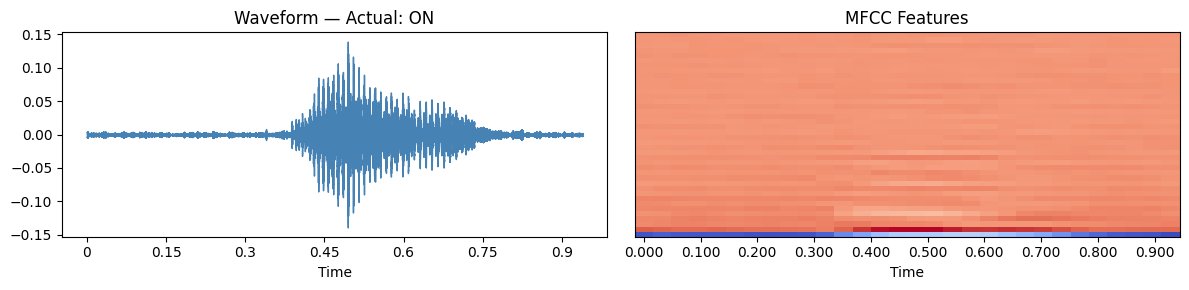

In [ ]:
# Test prediction on a random test file from the dataset
import random

test_cmd = random.choice(COMMANDS)
test_files = glob.glob(f'{DATA_DIR}/{test_cmd}/*.wav')
test_file = random.choice(test_files)

y_test_audio, sr_test = librosa.load(test_file, sr=SAMPLE_RATE)

label_rf,  prob_rf  = predict_from_array(y_test_audio, sr_test, model_choice='rf')
label_cnn, prob_cnn = predict_from_array(y_test_audio, sr_test, model_choice='cnn')

print('='*50)
print(f'  📁 File    : .../{test_cmd}/{os.path.basename(test_file)}')
print(f'  🏷️  Actual  : {test_cmd.upper()}')
print('-'*50)
print(f'  🌳 RF  predicted: {label_rf.upper()}  ({prob_rf*100:.1f}% confidence)')
print(f'  🧠 CNN predicted: {label_cnn.upper()}  ({prob_cnn*100:.1f}% confidence)')
print('='*50)

# Play the audio
display(Audio(test_file))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
librosa.display.waveshow(y_test_audio, sr=sr_test, ax=axes[0], color='steelblue')
axes[0].set_title(f'Waveform — Actual: {test_cmd.upper()}')
mfcc_test = librosa.feature.mfcc(y=y_test_audio, sr=sr_test, n_mfcc=N_MFCC)
librosa.display.specshow(mfcc_test, sr=sr_test, ax=axes[1], x_axis='time', cmap='coolwarm')
axes[1].set_title('MFCC Features')
plt.tight_layout(); plt.show()

---
## 🚀 Cell 12 — Upgrade Path: Arduino Serial Command Sender
> This shows how you would extend this to real IoT — send serial commands to Arduino

In [ ]:
# ============================================================
# ARDUINO UPGRADE SIMULATION
# On real hardware: pip install pyserial
# Then replace the simulated send with:
#   import serial
#   ser = serial.Serial('/dev/ttyUSB0', 9600)
#   ser.write(command.encode())
# ============================================================

COMMAND_TO_SIGNAL = {
    'on':   'LED_ON',
    'off':  'LED_OFF',
    'up':   'MOTOR_FWD',
    'down': 'MOTOR_REV',
    'yes':  'CONFIRM',
    'no':   'CANCEL',
}

def simulate_arduino_send(predicted_label, confidence, threshold=0.6):
    if confidence < threshold:
        print(f'⚠️  Low confidence ({confidence:.0%}) — command not sent')
        return

    signal = COMMAND_TO_SIGNAL.get(predicted_label, 'UNKNOWN')
    print(f'📡 [SERIAL] Sending → {signal}  (triggered by: "{predicted_label}", conf: {confidence:.0%})')
    # ser.write((signal + '\n').encode())  # ← uncomment on real hardware

# Demo run with all commands
print('🔌 Arduino Serial Command Simulation')
print('='*50)
for cmd in COMMANDS:
    f = random.choice(glob.glob(f'{DATA_DIR}/{cmd}/*.wav'))
    y_a, sr_a = librosa.load(f, sr=SAMPLE_RATE)
    label, prob = predict_from_array(y_a, sr_a, model_choice='cnn')
    simulate_arduino_send(label, prob)

print('\n🔧 Arduino sketch (C++) for the other end:')
print("""
  void loop() {
    if (Serial.available()) {
      String cmd = Serial.readStringUntil('\\n');
      if      (cmd == "LED_ON")   digitalWrite(LED_PIN, HIGH);
      else if (cmd == "LED_OFF")  digitalWrite(LED_PIN, LOW);
      else if (cmd == "MOTOR_FWD") motorForward();
      else if (cmd == "MOTOR_REV") motorReverse();
    }
  }
""")

🔌 Arduino Serial Command Simulation
📡 [SERIAL] Sending → CONFIRM  (triggered by: "yes", conf: 100%)
⚠️  Low confidence (48%) — command not sent
⚠️  Low confidence (56%) — command not sent
📡 [SERIAL] Sending → MOTOR_REV  (triggered by: "down", conf: 81%)
📡 [SERIAL] Sending → LED_ON  (triggered by: "on", conf: 98%)
📡 [SERIAL] Sending → LED_OFF  (triggered by: "off", conf: 100%)

🔧 Arduino sketch (C++) for the other end:

  void loop() {
    if (Serial.available()) {
      String cmd = Serial.readStringUntil('\n');
      if      (cmd == "LED_ON")   digitalWrite(LED_PIN, HIGH);
      else if (cmd == "LED_OFF")  digitalWrite(LED_PIN, LOW);
      else if (cmd == "MOTOR_FWD") motorForward();
      else if (cmd == "MOTOR_REV") motorReverse();
    }
  }



---
## 📈 Cell 13 — Feature Importance & Final Summary

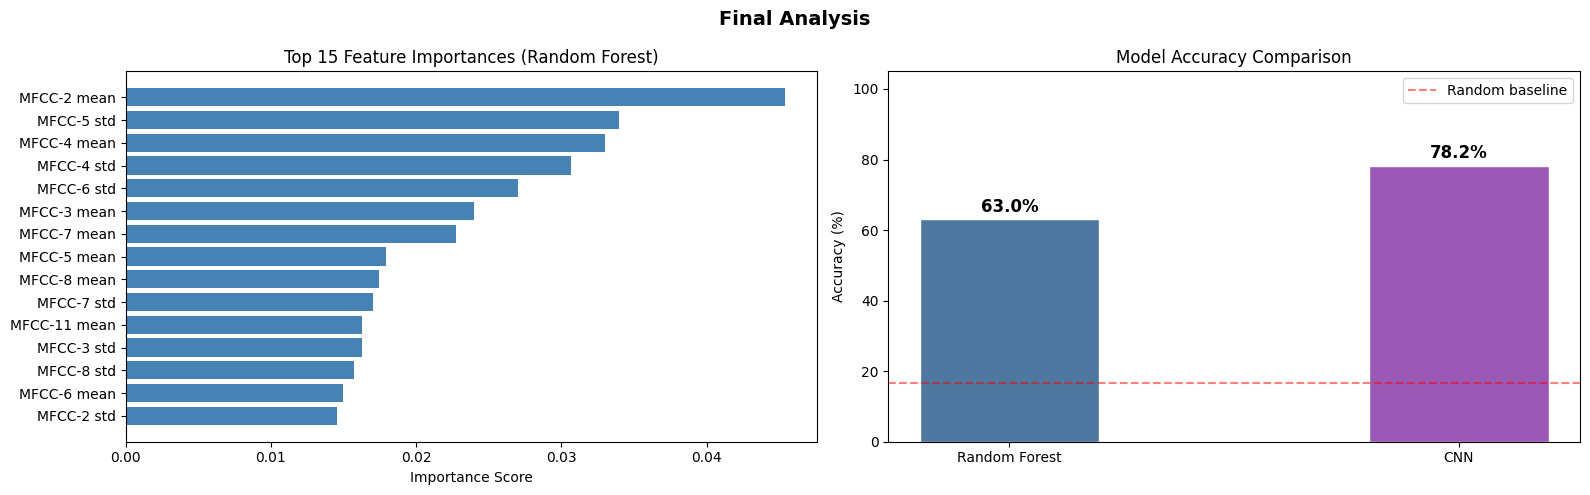


   🎤 VOICE COMMAND RECOGNITION — PROJECT SUMMARY
  Commands trained : YES, NO, UP, DOWN, ON, OFF
  Total samples    : 3000
  Feature type     : MFCC (40 coeffs × mean+std = 80 features)
  Random Forest    : 63.00% accuracy
  CNN              : 78.17% accuracy
  Random baseline  : 16.7% (chance level)
  📁 Saved files:
     /content/rf_voice_model.pkl
     /content/cnn_voice_model.h5
     /content/audio_visualization.png
     /content/evaluation.png
     /content/final_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Final Analysis', fontsize=14, fontweight='bold')

# Feature importances from Random Forest
importances = rf_model.feature_importances_
mfcc_names = ([f'MFCC-{i+1} mean' for i in range(N_MFCC)] +
              [f'MFCC-{i+1} std'  for i in range(N_MFCC)])
top_idx = np.argsort(importances)[-15:][::-1]

ax = axes[0]
bars = ax.barh([mfcc_names[i] for i in top_idx], importances[top_idx], color='steelblue')
ax.set_title('Top 15 Feature Importances (Random Forest)')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()

# Model accuracy comparison
ax = axes[1]
models = ['Random Forest', 'CNN']
accs   = [rf_acc * 100, cnn_acc * 100]
colors = ['#4e78a0', '#9b59b6']
bars2 = ax.bar(models, accs, color=colors, width=0.4, edgecolor='white')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
for bar, acc in zip(bars2, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.axhline(y=100/len(COMMANDS), color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()

plt.tight_layout()
plt.savefig('/content/final_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('   🎤 VOICE COMMAND RECOGNITION — PROJECT SUMMARY')
print('='*55)
print(f'  Commands trained : {", ".join([c.upper() for c in COMMANDS])}')
print(f'  Total samples    : {len(X_flat)}')
print(f'  Feature type     : MFCC ({N_MFCC} coeffs × mean+std = {N_MFCC*2} features)')
print(f'  Random Forest    : {rf_acc*100:.2f}% accuracy')
print(f'  CNN              : {cnn_acc*100:.2f}% accuracy')
print(f'  Random baseline  : {100/len(COMMANDS):.1f}% (chance level)')
print('='*55)
print('  📁 Saved files:')
print('     /content/rf_voice_model.pkl')
print('     /content/cnn_voice_model.h5')
print('     /content/audio_visualization.png')
print('     /content/evaluation.png')
print('     /content/final_analysis.png')
print('='*55)